In [1]:
import matplotlib.pyplot as plt
import numpy as np
from MarketSim import Market, LMSR, CFMM

LMSR Mean: -0.19533128357930632
LMSR Std: 4.2412955045070175
CFMM Mean: -0.12363261508701949
CFMM Std: 4.147931457374743


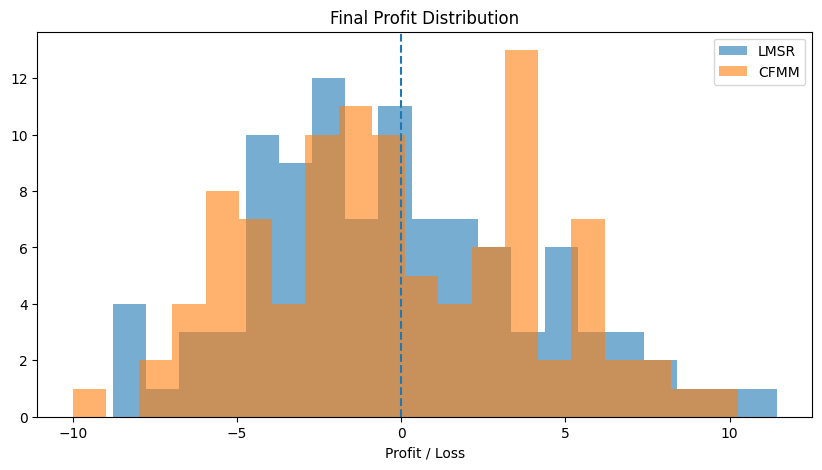

In [3]:
np.random.seed(42)

N_RUNS = 100
T = 1000
true_p = np.array([0.3, 0.7])
noise_ratio = 0.999

lmsr_b = 50
cfmm_k = lmsr_b ** 2

profits_lmsr = []
profits_cfmm = []

for _ in range(N_RUNS):

    lmsr = LMSR(n=2, b=lmsr_b)
    cfmm = CFMM(n=2, k_constant=cfmm_k)

    m1 = Market(lmsr, T, true_p, noise_ratio)
    m2 = Market(cfmm, T, true_p, noise_ratio)

    _, _, _, r1 = m1.run()
    _, _, _, r2 = m2.run()

    profits_lmsr.append(r1)
    profits_cfmm.append(r2)


# =========================
# STATS
# =========================

print("LMSR Mean:", np.mean(profits_lmsr))
print("LMSR Std:", np.std(profits_lmsr))

print("CFMM Mean:", np.mean(profits_cfmm))
print("CFMM Std:", np.std(profits_cfmm))


# =========================
# PLOTS
# =========================

plt.figure(figsize=(10, 5))

plt.hist(profits_lmsr, bins=20, alpha=0.6, label="LMSR")
plt.hist(profits_cfmm, bins=20, alpha=0.6, label="CFMM")

plt.axvline(0, linestyle='--')
plt.title("Final Profit Distribution")
plt.xlabel("Profit / Loss")
plt.legend()
plt.show()

# TODO
- Run sims where you vary only n
- Run sims where you vary only k
- Run sims where you vary only b
For each keep track of pnl and spread, plot them (the statistic of the distributions) with the theoretical worst case  
  
Might be fun to vary the noise parameter as well  

  
Write up the implementation in the report, and document this in the readme :( bleh